1. Importar librerias

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

2. Estudio preliminar

In [ ]:
df = pd.read_csv('/workspace/dataset.csv', sep=';')


In [27]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [29]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

In [30]:
df['wine_type'].unique()

array(['red', 'white'], dtype=object)

In [31]:
df.drop('wine_type', axis=1, inplace=True)
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


Dibujo boxplot para ver outliers

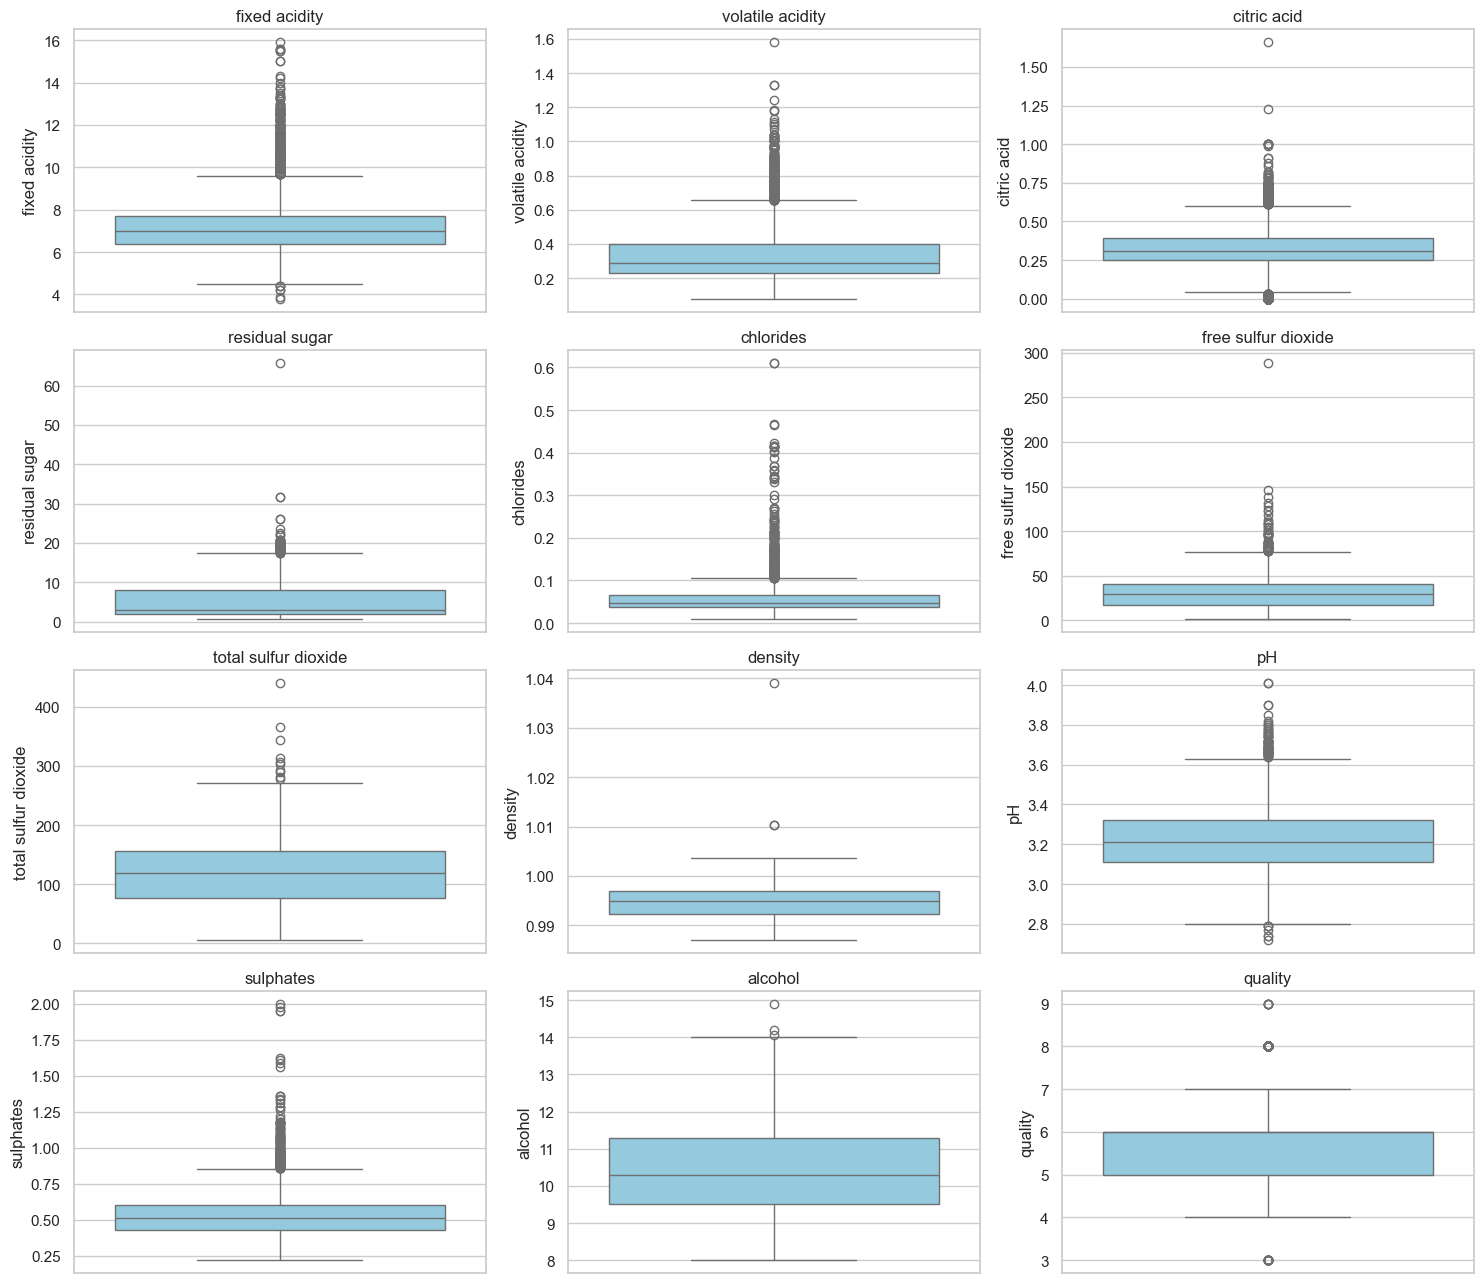

In [32]:
# Configuramos el estilo y el tamaño de la figura (cuadrícula de 4 filas x 3 columnas)
plt.figure(figsize=(15, 13))
sns.set_theme(style="whitegrid")

# Creamos un bucle para recorrer todas las columnas
for i, col in enumerate(df.columns):
    plt.subplot(4, 3, i + 1) # Crear un espacio para cada gráfico
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)
    plt.tight_layout()

plt.show()

Hacemos una limpieza de outliers calculando los limites superior e inferior a traves del rango intercuartilico y los cuartiles.

In [33]:
# Seleccionar columnas numéricas (excluyendo la variable objetivo si es categórica o no se debe tocar)
# Asumiendo que 'wine_type' es categórica y no se toca.
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

print("--- Detección y tratamiento de Outliers (Método IQR) ---\n")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identificar outliers para documentación
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    if len(outliers) > 0:
        print(f"Variable: {col}")
        print(f" - Límites: [{lower_bound:.4f}, {upper_bound:.4f}]")
        print(f" - Cantidad de anómalos detectados: {len(outliers)}")
        print(f" - Muestra de valores (primeros 5): {outliers.head().tolist()}")
        print("-" * 30)
    
    # Reemplazar outliers por los límites (Capping)
    # Los valores menores al límite inferior se reemplazan por lower_bound
    # Los valores mayores al límite superior se reemplazan por upper_bound
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("\nProceso de tratamiento de outliers finalizado. Los valores han sido reemplazados por los límites.")


--- Detección y tratamiento de Outliers (Método IQR) ---

Variable: fixed acidity
 - Límites: [4.4500, 9.6500]
 - Cantidad de anómalos detectados: 357
 - Muestra de valores (primeros 5): [11.2, 10.2, 9.7, 10.1, 11.5]
------------------------------
Variable: volatile acidity
 - Límites: [-0.0250, 0.6550]
 - Cantidad de anómalos detectados: 377
 - Muestra de valores (primeros 5): [0.7, 0.88, 0.76, 0.7, 0.66]
------------------------------
Variable: citric acid
 - Límites: [0.0400, 0.6000]
 - Cantidad de anómalos detectados: 509
 - Muestra de valores (primeros 5): [0.0, 0.0, 0.0, 0.0, 0.0]
------------------------------
Variable: residual sugar
 - Límites: [-7.6500, 17.5500]
 - Cantidad de anómalos detectados: 118
 - Muestra de valores (primeros 5): [20.7, 20.7, 19.25, 17.95, 17.95]
------------------------------
Variable: chlorides
 - Límites: [-0.0025, 0.1055]
 - Cantidad de anómalos detectados: 286
 - Muestra de valores (primeros 5): [0.114, 0.176, 0.17, 0.368, 0.341]
-----------------

Vuelvo a visualizar los boxplot

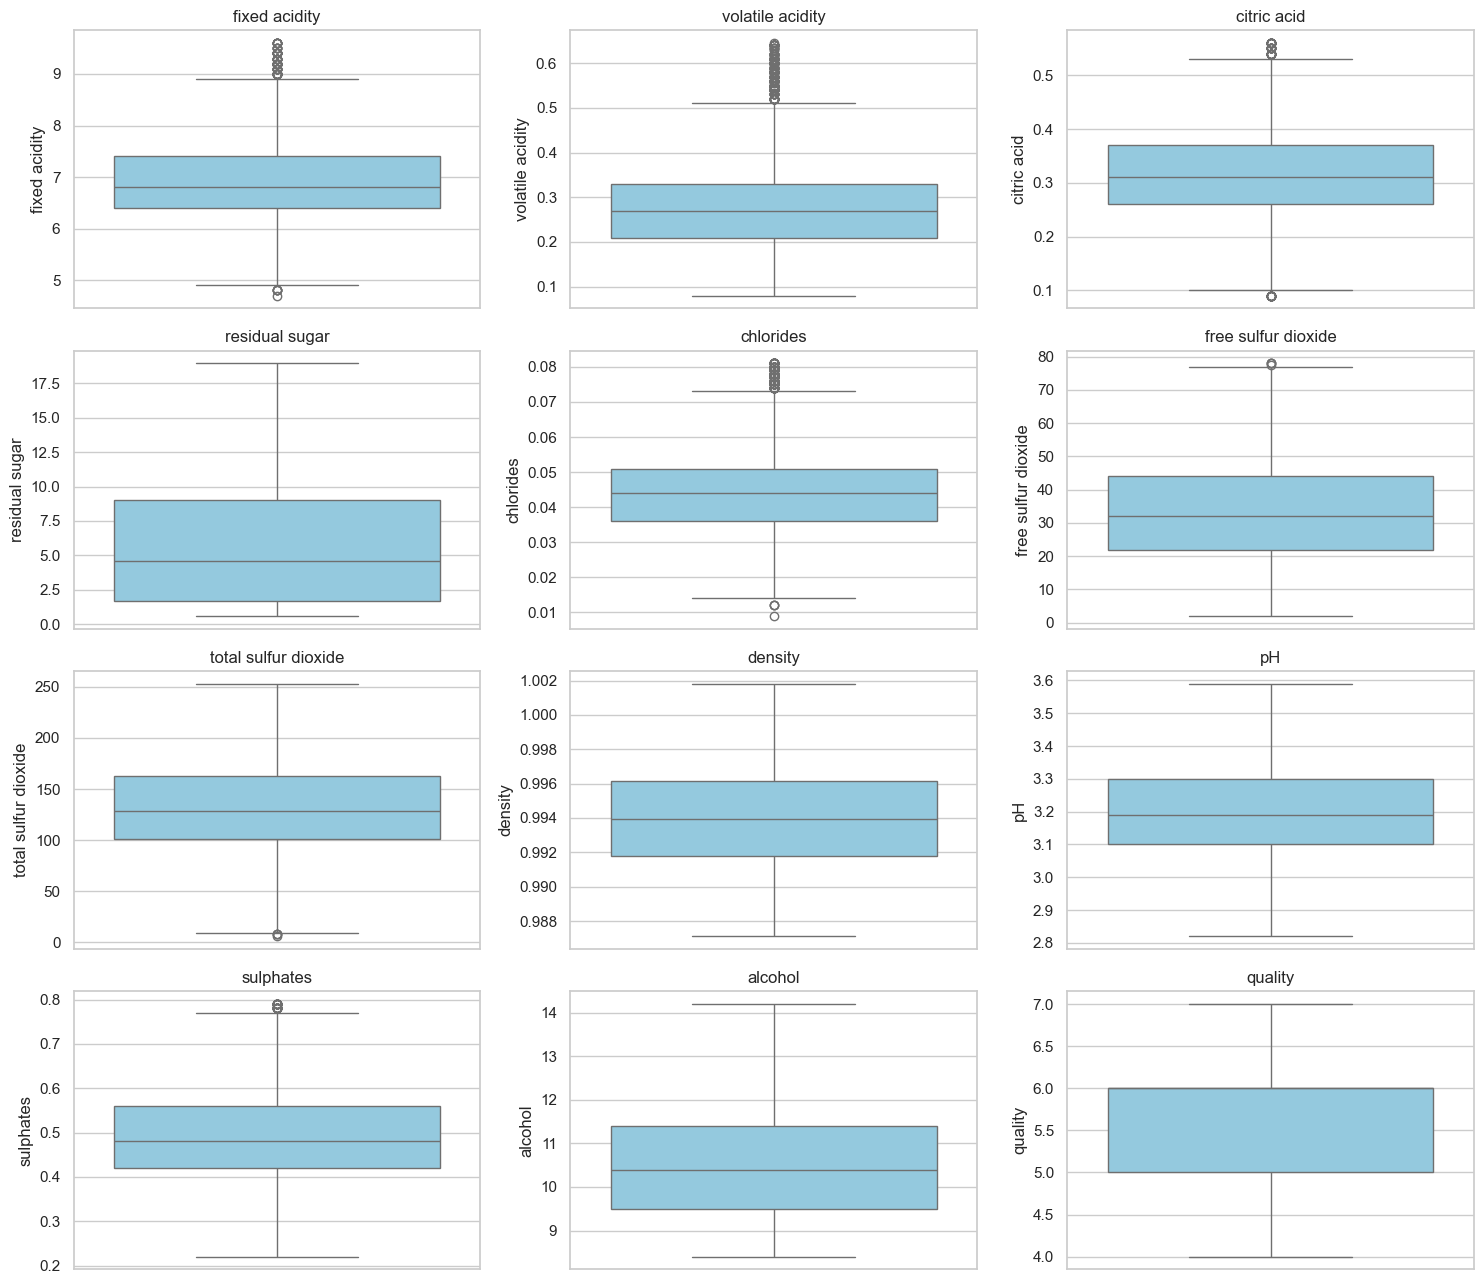

In [34]:
plt.figure(figsize=(15, 13))
sns.set_theme(style="whitegrid")

# Creamos un bucle para recorrer todas las columnas
for i, col in enumerate(df_clean.columns):
    plt.subplot(4, 3, i + 1) # Crear un espacio para cada gráfico
    sns.boxplot(y=df_clean[col], color="skyblue")
    plt.title(col)
    plt.tight_layout()

plt.show()

Escalado de datos:

Escalar las columnas numéricas seleccionadas utilizando MinMaxScaler y StandardScaler de Scikit-learn, aplicando cada scaler a las columnas correspondientes según su naturaleza.

Voy a usar:
- StandardScaler: para columnas con distribución normal (centra en 0 y escala a varianza 1) 
- MinMaxScaler: Para columnas donde los valores tienen límites naturales claros o distribuciones que no son normales, mejor sin outliers.

Dibujo histogramas para evr cuales se parecen mas a campana de gauss y por ende a la normal


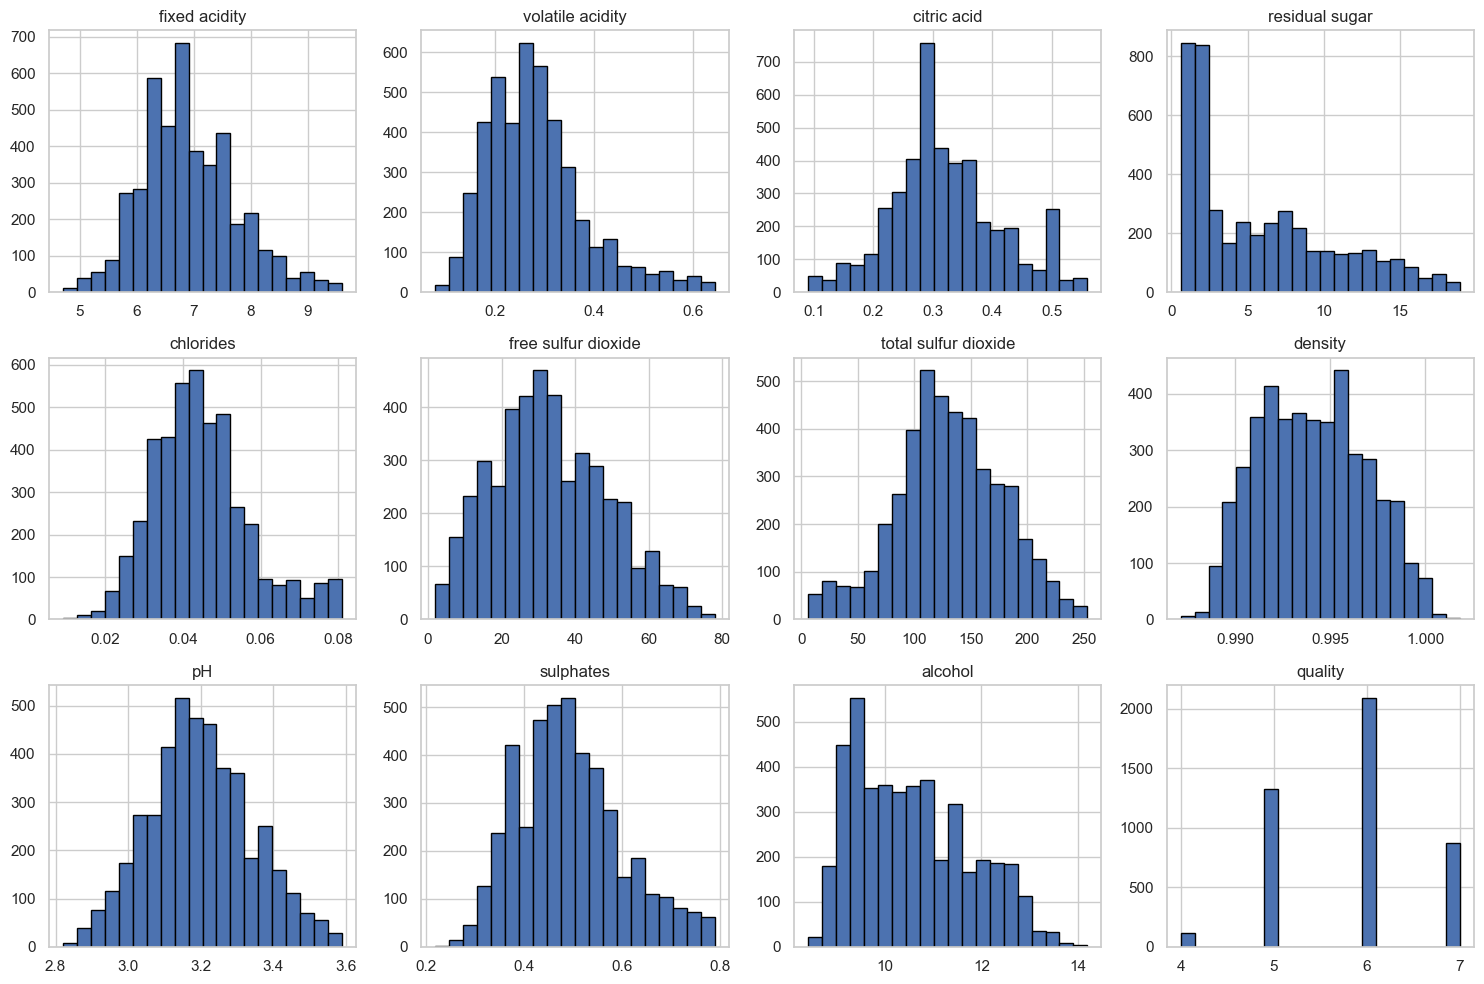

In [35]:
# Dibujar todas las columnas numéricas
df_clean.hist(bins=20, figsize=(15, 10), layout=(3, 4), edgecolor='black')

plt.tight_layout() # Para que no se encimen los títulos
plt.show()

In [36]:
# Definimos qué columnas van a cada escalador
# StandardScaler para variables con alta varianza
cols_standard = ['fixed acidity', 'volatile acidity', 'citric acid', 
                 'free sulfur dioxide', 'total sulfur dioxide', 'chlorides', 'pH', 'sulphates']

# MinMaxScaler para variables con rangos más acotados o proporciones 
cols_minmax = ['residual sugar', 'density', 'alcohol']


hago el escalado

In [37]:
# Crear una copia para los datos escalados
df_scaled = df_clean.copy()

# Inicializar los escaladores
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

# Aplicar StandardScaler
df_scaled[cols_standard] = scaler_std.fit_transform(df_clean[cols_standard])

# Aplicar MinMaxScaler
df_scaled[cols_minmax] = scaler_mm.fit_transform(df_clean[cols_minmax])

print(df_scaled[cols_standard + cols_minmax].head())

    fixed acidity  volatile acidity  citric acid  free sulfur dioxide  \
20       2.384097         -0.632939     1.767431            -0.262219   
25      -0.737006          1.052908    -1.768982            -1.428671   
26       0.823546          1.251243    -0.884879            -1.882291   
33      -0.016751          3.185009    -2.211033             0.450613   
37       1.423758          0.953741    -0.442827            -1.299065   

    total sulfur dioxide  chlorides        pH  sulphates  residual sugar  \
20             -1.495325   2.544862  1.325386   0.329527        0.065395   
25             -2.281962   2.781730  0.976005   0.608016        0.043597   
26             -2.537087   2.781730  0.556748   0.886505        0.065395   
33             -1.006335   2.229037  1.744643   0.236697        0.550409   
37             -2.133139   1.676344  0.207367   2.186122        0.081744   

     density   alcohol  
20  0.658736  0.172414  
25  0.570360  0.155172  
26  0.617947  0.189655  
33  

Verificamos si ha funcionado el escalado

--- Estadísticas descriptivas del dataset escalado ---
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count        4418.00           4418.00      4418.00         4418.00   
mean            0.00             -0.00         0.00            0.29   
std             1.00              1.00         1.00            0.26   
min            -2.66             -2.02        -2.54            0.00   
25%            -0.62             -0.73        -0.66            0.06   
50%            -0.14             -0.14        -0.11            0.22   
75%             0.58              0.46         0.55            0.46   
max             3.22              3.58         2.65            1.00   

       chlorides  free sulfur dioxide  total sulfur dioxide  density       pH  \
count    4418.00              4418.00               4418.00  4418.00  4418.00   
mean        0.00                 0.00                 -0.00     0.47     0.00   
std         1.00                 1.00                  1.00   

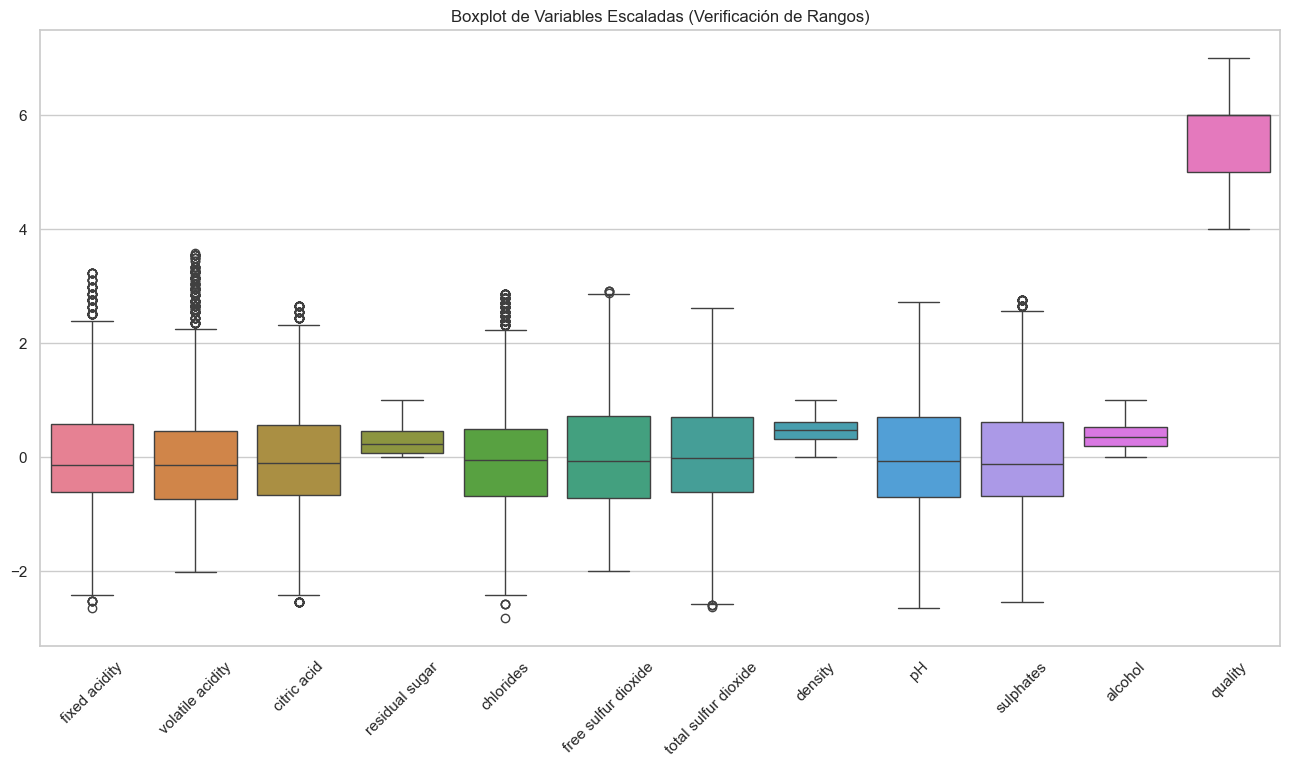

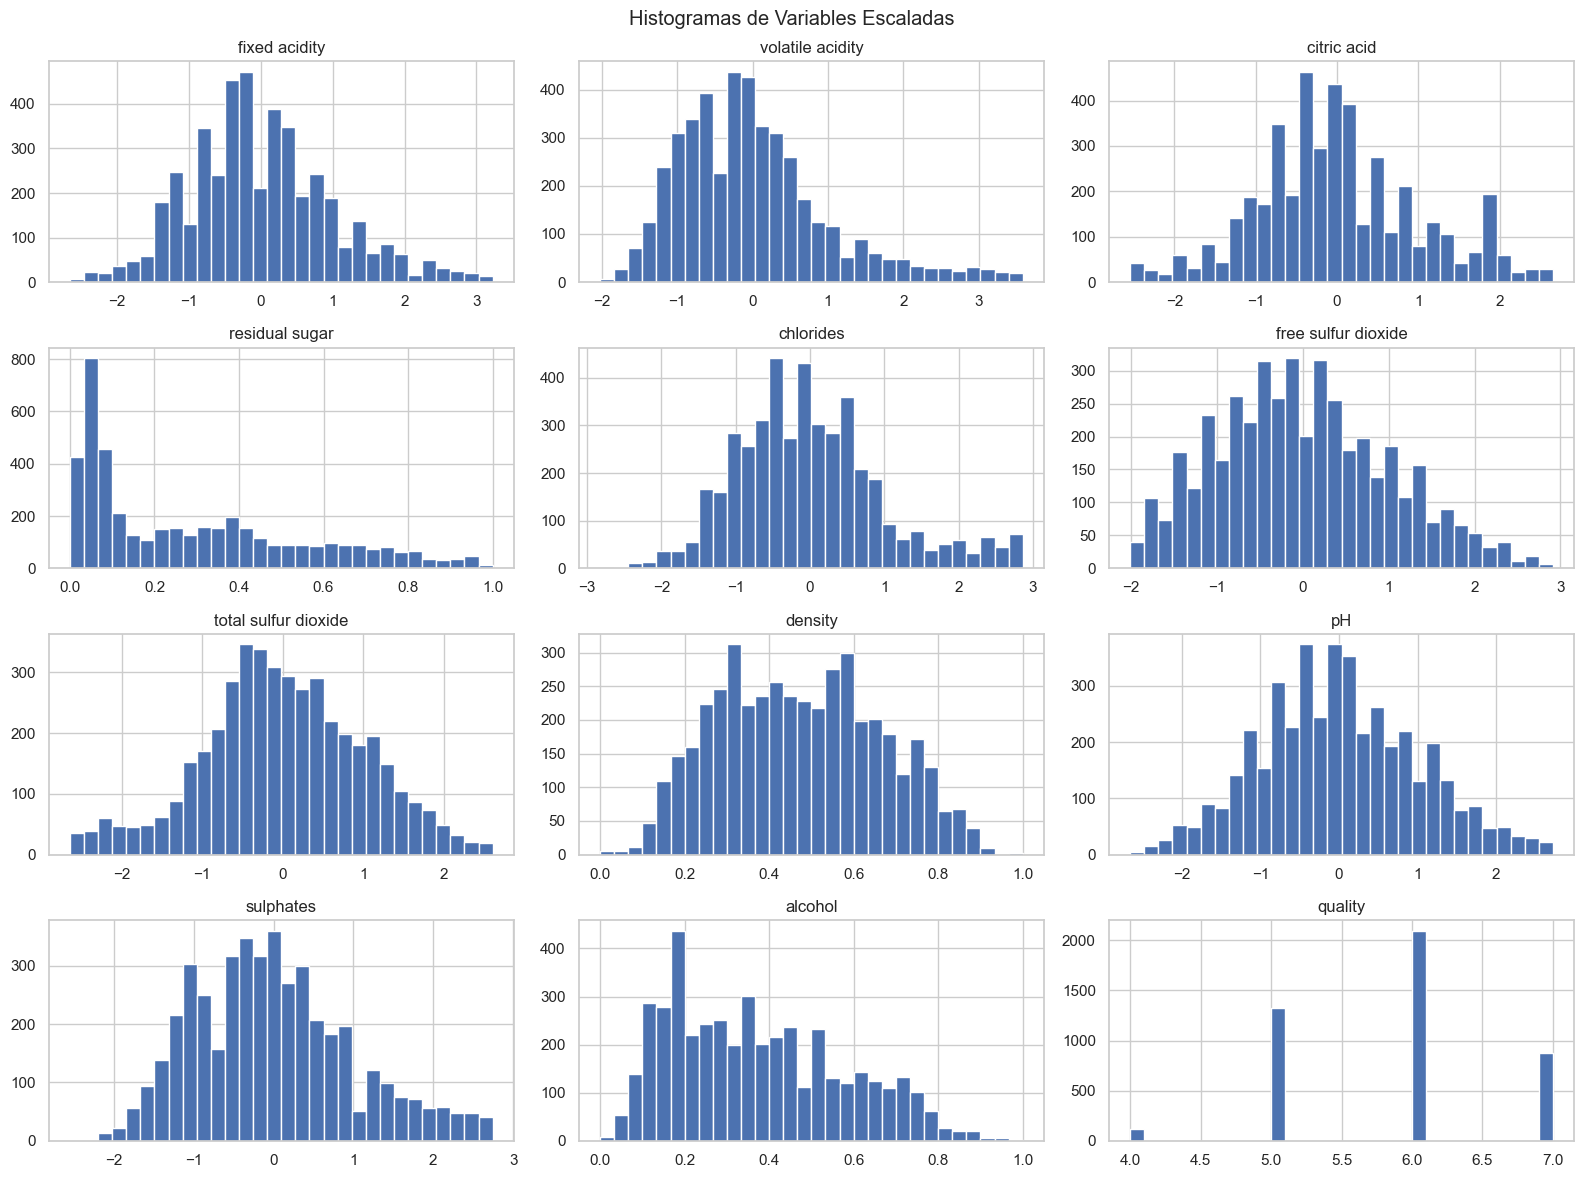

In [38]:
# Suponiendo que 'df_scaled' es el DataFrame con las variables ya escaladas.
# 1. Imprimir estadísticas para verificar media ~0 y std ~1 (si usaste StandardScaler)
print("--- Estadísticas descriptivas del dataset escalado ---")
print(df_scaled.describe().round(2))

# 2. Generar Boxplots para visualizar la distribución y outliers en la misma escala
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_scaled)
plt.title("Boxplot de Variables Escaladas (Verificación de Rangos)")
plt.xticks(rotation=45)
plt.show()

# 3. Generar Histogramas para ver la forma de la distribución
df_scaled.hist(figsize=(16, 12), bins=30)
plt.suptitle("Histogramas de Variables Escaladas")
plt.tight_layout()
plt.show()


In [ ]:
df_scaled.to_csv('/workspace/dataset_scaled.csv', index=False)